# BrainTumNet End-to-End Workflow

This notebook guides you through the complete pipeline used in the BrainTumNet project:

- Environment validation
- Data preprocessing (NIfTI → PNG → LMDB)
- Exploratory analysis of the slice-level dataset
- Configuration management and dataset construction
- Quick visual sanity checks
- (Optional) model training, evaluation, and inference hooks

Each major section includes Markdown explanations and optional code blocks you can enable as needed. By default, heavy operations (full preprocessing, full training) are disabled so you can review the workflow safely before running expensive jobs.

## 0. Environment Setup

Establish project paths, import core libraries, and record environment details for reproducibility.

In [10]:
import os
import sys
import platform
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "braintumnet").exists():
    # Fallback: assume notebook lives in notebooks/ sibling
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_ROOT = PROJECT_ROOT / "braintumnet" / "src"
sys.path.insert(0, str(SRC_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Source path added: {SRC_ROOT}")

Project root: E:\thong\code\brain_segmen
Source path added: E:\thong\code\brain_segmen\braintumnet\src


In [11]:
import torch
import numpy as np
import pandas as pd

print(f"Python version: {platform.python_version()}")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    print(f"CUDA detected. Default device: {device_name}")
else:
    print("CUDA not available - computations will run on CPU.")

Python version: 3.10.18
PyTorch version: 2.5.0+cu118
NumPy version: 2.2.6
Pandas version: 2.3.3
CUDA detected. Default device: NVIDIA GeForce RTX 3090


## 1. Load and Merge Configuration

The project composes configuration files (`base.yaml` + model-specific + optional hardware overrides). We replicate the logic used in `scripts/train.py` to obtain a single `cfg` dictionary that downstream stages consume.

In [12]:
import yaml
from copy import deepcopy

def load_yaml(path: Path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

def merge_configs(base_cfg, override_cfg):
    merged = deepcopy(base_cfg)
    for key, value in override_cfg.items():
        if key in merged and isinstance(merged[key], dict) and isinstance(value, dict):
            merged[key] = merge_configs(merged[key], value)
        else:
            merged[key] = deepcopy(value)
    return merged

# --- Select configuration files ---
BASE_CFG_PATH = PROJECT_ROOT / "braintumnet" / "configs" / "base.yaml"
MODEL_NAME = "swin_unetr"  # change to "segunetv2" / "nnunet" / "unetr" / ... as needed
MODEL_CFG_PATH = PROJECT_ROOT / "braintumnet" / "configs" / "models" / f"{MODEL_NAME}.yaml"
HARDWARE_PROFILE = None  # set to "a100" to load hardware override

cfg = load_yaml(BASE_CFG_PATH)
if MODEL_CFG_PATH.exists():
    cfg = merge_configs(cfg, load_yaml(MODEL_CFG_PATH))
if HARDWARE_PROFILE:
    HW_CFG_PATH = PROJECT_ROOT / "braintumnet" / "configs" / f"hardware_{HARDWARE_PROFILE}.yaml"
    if HW_CFG_PATH.exists():
        hw_cfg = load_yaml(HW_CFG_PATH)
        cfg = merge_configs(cfg, hw_cfg)
        if 'model_batch_sizes' in hw_cfg and MODEL_NAME in hw_cfg['model_batch_sizes']:
            cfg['train']['batch_size'] = hw_cfg['model_batch_sizes'][MODEL_NAME]

print(f"Active model: {cfg['model']['model_type']}")

Active model: swin_unetr


In [13]:
from pprint import pprint
print("Configuration summary (truncated):")
pprint({
    "data": {k: cfg['data'][k] for k in ['backend', 'raw_root', 'proc_root', 'lmdb_root', 'fold']},
    "train": {k: cfg['train'][k] for k in ['epochs', 'batch_size', 'lr', 'loss_type', 'dice_weight', 'focal_weight']},
    "model": {k: cfg['model'][k] for k in ['model_type', 'in_channels', 'num_classes_seg']},
})

Configuration summary (truncated):
{'data': {'backend': 'lmdb',
          'fold': 0,
          'lmdb_root': 'braintumnet/data/lmdb_processed_multiclass_full',
          'proc_root': 'braintumnet/data/processed_multiclass_full',
          'raw_root': 'braintumnet/data/raw/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'},
 'model': {'in_channels': 4, 'model_type': 'swin_unetr', 'num_classes_seg': 3},
 'train': {'batch_size': 14,
           'dice_weight': 1.0,
           'epochs': 400,
           'focal_weight': 1.0,
           'loss_type': 'dice_focal',
           'lr': 5e-05}}


In [14]:
def resolve_path(path_str):
    """Convert config path (possibly relative) to an absolute Path."""
    path = Path(path_str)
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    return path.resolve()

# Normalize key data paths in-place so downstream code receives absolute paths
cfg['data']['raw_root'] = str(resolve_path(cfg['data']['raw_root']))
cfg['data']['proc_root'] = str(resolve_path(cfg['data']['proc_root']))
cfg['data']['lmdb_root'] = str(resolve_path(cfg['data'].get('lmdb_root', cfg['data']['proc_root'])))

## 2. Data Preparation Pipeline

The workflow consists of three main preprocessing steps:

1. **NIfTI → Multi-class PNG slices** (`scripts/preprocess_nifti_to_multiclass.py`)
2. **PNG → LMDB conversion** for faster I/O (`scripts/convert_to_lmdb.py`)
3. **Quality checks & metadata validation** (`scripts/benchmark_dataloader.py`, `notebooks/dataset_eda.ipynb`)

The commands below are disabled by default—set the corresponding flag to `True` if you need to run the step. All paths derive from the merged configuration to avoid manual typos.

In [15]:
RUN_PREPROCESS = False  # <- change to True to execute the conversion

raw_root = Path(cfg['data']['raw_root'])
png_out = Path(cfg['data']['proc_root'])
lmdb_out = Path(cfg['data']['lmdb_root'])

if RUN_PREPROCESS:
    %run ../braintumnet/scripts/preprocess_nifti_to_multiclass.py \
        --nifti_dir {raw_root.as_posix()} \
        --out_dir {png_out.as_posix()} \
        --img_size {cfg['data']['img_size']} \
        --slices_per_case {cfg['data']['slices_per_case']} \
        --num_folds {cfg['data']['num_folds']}
else:
    print("Skipping NIfTI→PNG preprocessing. Set RUN_PREPROCESS=True to execute.")

Skipping NIfTI→PNG preprocessing. Set RUN_PREPROCESS=True to execute.


In [16]:
RUN_LMDB_CONVERSION = False  # <- enable if LMDB needs to be regenerated

if RUN_LMDB_CONVERSION:
    %run ../braintumnet/scripts/convert_to_lmdb.py \
        --png_root {png_out.as_posix()} \
        --lmdb_root {lmdb_out.as_posix()} \
        --num_workers 8
else:
    print("Skipping PNG→LMDB conversion. Set RUN_LMDB_CONVERSION=True to execute.")

Skipping PNG→LMDB conversion. Set RUN_LMDB_CONVERSION=True to execute.


## 3. Dataset Sanity Checks & Exploratory Analysis

Inspect the slice split files produced during preprocessing and compute basic label statistics to make sure the dataset looks correct before training.

In [17]:
fold = cfg['data']['fold']
train_split = Path(lmdb_out) / f"train_fold{fold}.csv"
val_split = Path(lmdb_out) / f"val_fold{fold}.csv"

print(f"Train split: {train_split}")
print(f"Val split:   {val_split}")

if not train_split.exists() or not val_split.exists():
    print("\n⚠️  Split files not found. Run the preprocessing steps (NIfTI→PNG and PNG→LMDB) to generate train/val CSVs.")
else:
    train_df = pd.read_csv(train_split)
    val_df = pd.read_csv(val_split)
    display(train_df.head())
    display(val_df.head())
    print(f"Train slices: {len(train_df):,}")
    print(f"Val slices:   {len(val_df):,}")

Train split: E:\thong\code\brain_segmen\braintumnet\data\lmdb_processed_multiclass_full\train_fold0.csv
Val split:   E:\thong\code\brain_segmen\braintumnet\data\lmdb_processed_multiclass_full\val_fold0.csv


,slice_id,case_id,slice_idx,label,has_wt,has_tc,has_ed
0,BraTS20_Training_002_slice000,BraTS20_Training_002,0,Normal,0,0,0
1,BraTS20_Training_002_slice001,BraTS20_Training_002,1,Normal,0,0,0
2,BraTS20_Training_002_slice002,BraTS20_Training_002,2,Normal,0,0,0
3,BraTS20_Training_002_slice003,BraTS20_Training_002,3,Normal,0,0,0
4,BraTS20_Training_002_slice004,BraTS20_Training_002,4,Normal,0,0,0


,slice_id,case_id,slice_idx,label,has_wt,has_tc,has_ed
0,BraTS20_Training_001_slice000,BraTS20_Training_001,0,Normal,0,0,0
1,BraTS20_Training_001_slice001,BraTS20_Training_001,1,Normal,0,0,0
2,BraTS20_Training_001_slice002,BraTS20_Training_001,2,Normal,0,0,0
3,BraTS20_Training_001_slice003,BraTS20_Training_001,3,Normal,0,0,0
4,BraTS20_Training_001_slice004,BraTS20_Training_001,4,Normal,0,0,0


Train slices: 45,570
Val slices:   11,470


In [18]:
from braintumnet.data.dataset_factory import create_dataset, get_data_root

dataset_cfg = deepcopy(cfg)
dataset_cfg['train']['workers'] = min(2, dataset_cfg['train']['workers'])  # keep notebook-friendly
dataset_cfg['train']['batch_size'] = min(4, dataset_cfg['train']['batch_size'])

data_root = get_data_root(dataset_cfg)
data_root = resolve_path(data_root)
dataset_cfg['data']['lmdb_root'] = str(resolve_path(dataset_cfg['data']['lmdb_root']))
dataset_cfg['data']['proc_root'] = str(resolve_path(dataset_cfg['data']['proc_root']))
train_ds = create_dataset(
    backend=dataset_cfg['data']['backend'],
    data_root=str(data_root),
    split_file=str(train_split),
    cfg=dataset_cfg,
    train=True,
)
val_ds = create_dataset(
    backend=dataset_cfg['data']['backend'],
    data_root=str(data_root),
    split_file=str(val_split),
    cfg=dataset_cfg,
    train=False,
)

print(f"Loaded training dataset with {len(train_ds):,} slices")
print(f"Loaded validation dataset with {len(val_ds):,} slices")

  Using LMDB backend (LMDBDataset) - Fast loading!
  Using LMDB backend (LMDBDataset) - Fast loading!
Loaded training dataset with 45,570 slices
Loaded validation dataset with 11,470 slices


### 3.1 Class Distribution Snapshot

Iterate through a small subset of training slices to verify class coverage. This is not a full dataset scan (which would be expensive) but gives a quick sense of label presence.

In [19]:
from collections import defaultdict
from tqdm.auto import tqdm

num_classes = dataset_cfg['model']['num_classes_seg']
class_counts = torch.zeros(num_classes, dtype=torch.long)
samples_to_scan = min(512, len(train_ds))

for idx in tqdm(range(samples_to_scan), desc="Scanning slices"):
    sample = train_ds[idx]
    mask = sample['mask'].view(-1)
    counts = torch.bincount(mask, minlength=num_classes)
    class_counts += counts

total_pixels = class_counts.sum().item()
for c in range(num_classes):
    pct = (class_counts[c].item() / total_pixels) * 100 if total_pixels > 0 else 0
    print(f"Class {c}: {class_counts[c].item():>12,} pixels ({pct:6.3f}%)")

Scanning slices: 100%|██████████| 512/512 [00:00<00:00, 1784.64it/s]

Class 0:   33,415,319 pixels (99.585%)
Class 1:       39,337 pixels ( 0.117%)
Class 2:       99,776 pixels ( 0.297%)


### 3.2 Visualize a Sample Slice

Plot the four MRI modalities next to the multi-class mask to visually confirm the preprocessing, normalization, and label mapping.

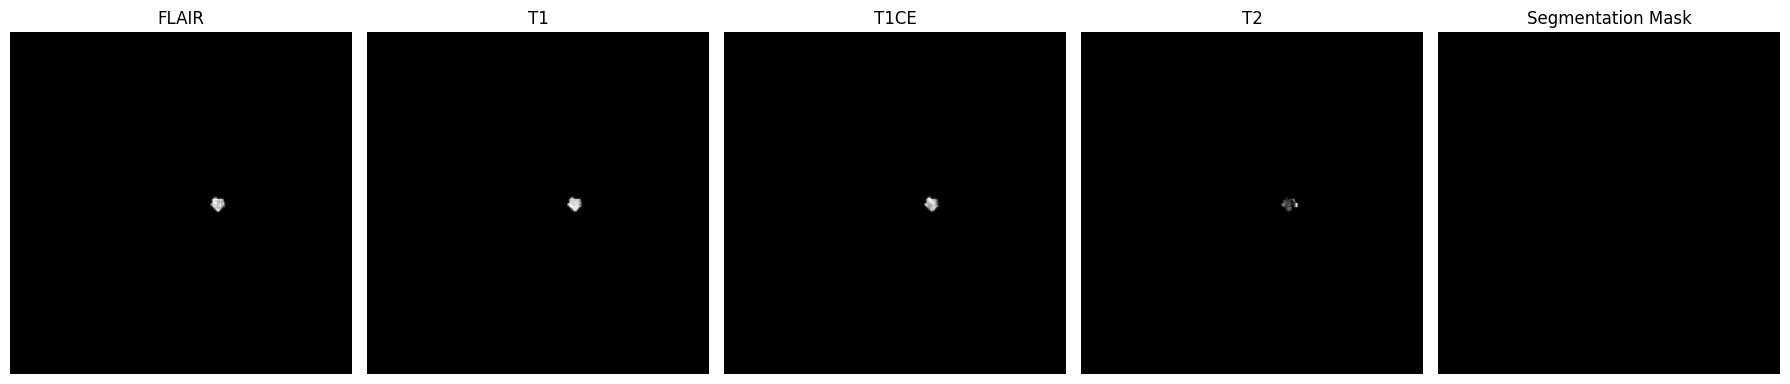

In [20]:
import matplotlib.pyplot as plt

sample = train_ds[0]
modalities = ['FLAIR', 'T1', 'T1CE', 'T2']
image = sample['image'].numpy()
mask = sample['mask'].squeeze(0).numpy()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i in range(image.shape[0]):
    axes[i].imshow(image[i], cmap='gray')
    axes[i].set_title(modalities[i])
    axes[i].axis('off')

color_map = np.zeros((*mask.shape, 3), dtype=np.float32)
color_map[mask == 1] = [1.0, 0.0, 0.0]  # Tumor Core -> red
color_map[mask == 2] = [0.0, 1.0, 0.0]  # Edema -> green

axes[-1].imshow(color_map)
axes[-1].set_title('Segmentation Mask')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 4. DataLoader Construction

Use the same factory used in `engine/trainer.py` to build production-ready `DataLoader` objects. We deliberately reduce batch size and workers here to keep the notebook responsive.

In [21]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=dataset_cfg['train']['batch_size'],
    shuffle=True,
    num_workers=dataset_cfg['train']['workers'],
    pin_memory=dataset_cfg['train'].get('pin_memory', True),
)
val_loader = DataLoader(
    val_ds,
    batch_size=min(dataset_cfg['train'].get('val_batch_size', dataset_cfg['train']['batch_size']), 8),
    shuffle=False,
    num_workers=dataset_cfg['train']['workers'],
    pin_memory=dataset_cfg['train'].get('pin_memory', True),
)

print(f"Train loader batches per epoch: {len(train_loader):,}")
print(f"Val loader batches per epoch:   {len(val_loader):,}")

Train loader batches per epoch: 11,393
Val loader batches per epoch:   1,434


## 5. Optional Quick Sanity Training

To ensure the end-to-end pipeline is wired correctly, you can run a short training session (e.g., a single epoch with drastically reduced batch size). This relies on the same `train_one_fold` routine used by production scripts. **Warning:** even a single epoch is computationally heavy; keep the flags off unless you explicitly want to exercise the trainer.

In [22]:
RUN_TRAINING = False  # <- Enable with caution; this can take several minutes even for 1 epoch

if RUN_TRAINING:
    quick_cfg = deepcopy(cfg)
    quick_cfg['data']['fold'] = fold
    quick_cfg['train']['epochs'] = 1
    quick_cfg['train']['val_interval'] = 1
    quick_cfg['train']['batch_size'] = min(quick_cfg['train']['batch_size'], 4)
    quick_cfg['train']['workers'] = min(quick_cfg['train']['workers'], 4)
    quick_cfg['logging']['exp_name'] = f"notebook_{MODEL_NAME}_debug"

    from braintumnet.engine.trainer import train_one_fold
    best_iou = train_one_fold(quick_cfg, fold, config_path=None, resume_from=None)
    print(f"Notebook sanity training complete. Best IoU: {best_iou:.4f}")
else:
    print("Training skipped. Set RUN_TRAINING=True to run a quick debug epoch.")

Training skipped. Set RUN_TRAINING=True to run a quick debug epoch.


## 6. Evaluation Utilities

After training completes (either via the notebook or the CLI), use the evaluation script to compute validation metrics from saved checkpoints. Provide the checkpoint path generated in `checkpoints/`.

In [23]:
RUN_EVAL = False
CHECKPOINT_PATH = PROJECT_ROOT / "braintumnet" / "checkpoints" / "best_fold0.pth"  # adjust as needed

if RUN_EVAL:
    !python ../braintumnet/scripts/evaluate.py --model {MODEL_NAME} --ckpt {CHECKPOINT_PATH}
else:
    print("Evaluation skipped. Update CHECKPOINT_PATH and set RUN_EVAL=True when ready.")

Evaluation skipped. Update CHECKPOINT_PATH and set RUN_EVAL=True when ready.


## 7. Inference & Submission Artifacts

Generate predictions for new cases (or validation slices) using the inference script. This section mirrors the CLI but exposes configuration inside the notebook for quick experimentation.

In [24]:
RUN_INFERENCE = False
INFERENCE_INPUT = PROJECT_ROOT / "braintumnet" / "data" / "inference_samples"  # folder with prepared PNG slices
INFERENCE_OUTPUT = PROJECT_ROOT / "braintumnet" / "outputs" / "notebook_predictions"

if RUN_INFERENCE:
    !python ../braintumnet/scripts/predict.py --model {MODEL_NAME} --ckpt {CHECKPOINT_PATH} --input_dir {INFERENCE_INPUT} --output_dir {INFERENCE_OUTPUT}
else:
    print("Inference skipped. Configure paths and set RUN_INFERENCE=True to generate predictions.")

Inference skipped. Configure paths and set RUN_INFERENCE=True to generate predictions.


## 8. Training Logs & Monitoring

Training logs and TensorBoard summaries are saved under the directories specified in configuration. The utilities below help inspect run history directly from the notebook.

In [25]:
logs_dir = PROJECT_ROOT / cfg['logging']['log_dir']
runs_dir = PROJECT_ROOT / cfg['logging']['out_dir']
print(f"Logs directory:        {logs_dir}")
print(f"TensorBoard directory: {runs_dir}")
if logs_dir.exists():
    recent_logs = sorted(logs_dir.glob('**/*.log'))[-5:]
    for log_path in recent_logs:
        print(f"- {log_path}")
else:
    print("No logs found yet. Run training to populate log files.")

Logs directory:        E:\thong\code\brain_segmen\logs
TensorBoard directory: E:\thong\code\brain_segmen\runs
- E:\thong\code\brain_segmen\logs\swin_unetr_fold3_fold3_20251103_135221.log
- E:\thong\code\brain_segmen\logs\swin_unetr_fold3_fold3_20251103_135356.log
- E:\thong\code\brain_segmen\logs\swin_unetr_fold3_fold3_20251103_135710.log
- E:\thong\code\brain_segmen\logs\swin_unetr_fold3_fold3_20251103_140332.log
- E:\thong\code\brain_segmen\logs\swin_unetr_fold3_fold3_20251103_141933.log


## 9. Next Steps & Troubleshooting

- To debug data loading performance, run `scripts/benchmark_dataloader.py` with the same configuration to measure throughput.
- For detailed troubleshooting, consult the technical documents under `docs/v_technical/` (e.g., `v_08_TROUBLESHOOTING.md`).
- Keep an eye on class imbalance—tune `focal_alpha`, `class_weights`, and `dice_weight` as needed.
- When switching models (e.g., `segunetv2`, `nnunet`), update `MODEL_NAME` and regenerate the merged configuration before running the pipeline sections.

This notebook serves as a living checklist. Adapt paths, flags, and hyperparameters based on the specific experiment or hardware profile you are targeting.